###  تحميل البيانات والمعاينة المبدئية (Data Loading & Initial Inspection)

في هذه الخطوة الأولى تم تجهيز البيئة وقراءة ملف البيانات:
1. **استيراد المكتبات:** استيراد مكتبتي `pandas` و `numpy` للتعامل مع البيانات والجداول.
2. **تحميل الملف:** قراءة ملف البيانات (`house_prices.csv`) باستخدام `pd.read_csv`.
3. **فحص أبعاد البيانات:** عرض عدد الصفوف والأعمدة (`df.shape`).
4. **المعاينة الأولى:** عرض أول 5 صفوف لملاحظة شكل البيانات وأنواعها (`df.head`).
5. **معلومات ونسبة المفقود:** التحقق من أنواع البيانات والأعمدة (`df.info`) وحساب نسبة القيم المفقودة في كل عمود.
٦.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

df = pd.read_csv("c:\\Users\\CityLap\\Downloads\\archive\\house_prices.csv")

In [102]:
import pandas as pd
import numpy as np

# تحميل البيانات من مجلد data
df = pd.read_csv("c:\\Users\\CityLap\\Downloads\\archive\\house_prices.csv")

# 1. عرض حجم البيانات
print("Shape of Dataset:", df.shape)

# 2. عرض أول 5 صفوف
print("\n--- First 5 Rows ---")
display(df.head())

# 3. عرض معلومات الأعمدة وأنواعها
print("\n--- Data Information ---")
df.info()

# 4. عرض نسبة القيم المفقودة في كل عمود
print("\n--- Missing Values Percentage ---")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

Shape of Dataset: (187531, 21)

--- First 5 Rows ---


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  

###  استكشاف البيانات وتحليلها بيانيًا (Exploratory Data Analysis - EDA)

في هذه الخطوة تم استخدام الرسم البياني لفهم توزيع المتغيرات الأساسية:
1. **توزيع الأسعار (Target Variable):** رسم مدرج تكراري (`sns.histplot`) لمعرفة طبيعة توزيع أسعار العقارات واكتشاف الالتواء (Skewness) والقيم الشاذة.
2. **أكثر المناطق تكرارًا (Top Locations):** رسم مخطط شريطي (`sns.barplot`) لأكثر 10 مواقع تحتوي على معروض عقاري في مجموعة البيانات.
٣.

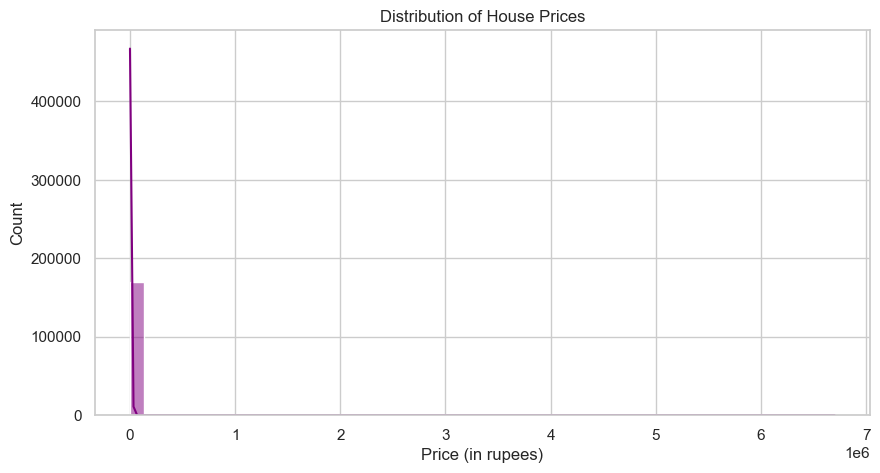

C:\Users\CityLap\AppData\Local\Temp\ipykernel_17812\3532438317.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')


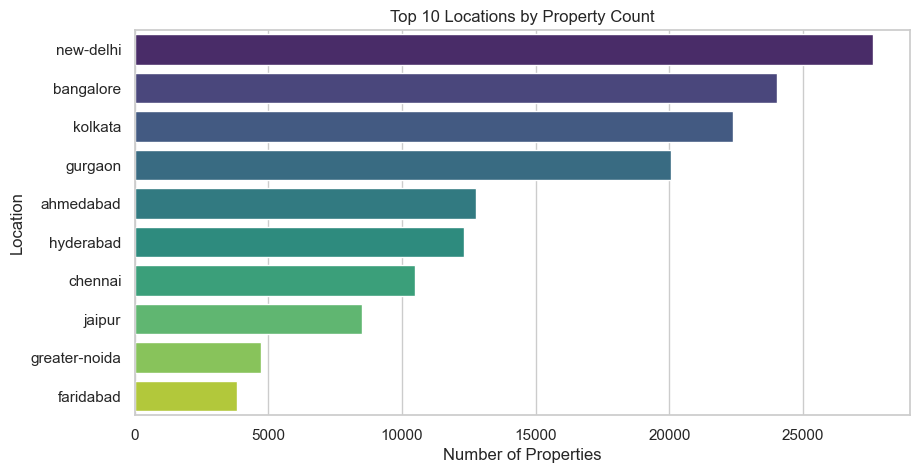

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# ضبط شكل الرسوم البيانية
sns.set_theme(style="whitegrid")

# 1. توزيع الأسعار (Distribution of Target Variable)
plt.figure(figsize=(10, 5))
sns.histplot(df['Price (in rupees)'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of House Prices')
plt.xlabel('Price (in rupees)')
plt.ylabel('Count')
plt.show()

# 2. أكثر 10 مواقع تكراراً (Top 10 Locations)
plt.figure(figsize=(10, 5))
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 Locations by Property Count')
plt.xlabel('Number of Properties')
plt.ylabel('Location')
plt.show()

###  معالجة وتنظيف البيانات (Feature Cleaning & Imputation)

في هذه الخطوة تم البدء في تجهيز البيانات الرقمية وتطهيرها:
1. **استخراج المساحة الرقمية:** استخراج الأرقام فقط من عمود `Carpet Area` باستخدام التعبيرات النمطية (`str.extract`) وتحويلها إلى نوع `float`.
2. **معالجة القيم المفقودة:** تعبئة القيم المفقودة (Missing Values) في المساحة باستخدام القيمة الوسطية (`median`) للحد من تأثير القيم الشاذة.
3. **الفحص والإحصاء:** التحقق من المتبقي من القيم المفقودة وعرض الإحصائيات الوصفية الأساسية (المتوسط، الأقل، والأعلى) للوقوف على جودة البيانات.
٤.

In [104]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

# تجميع المناطق الشائعة
top_locations = df['location'].value_counts().head(50).index
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_locations else 'other')

In [105]:
# 1. تنظيف عمود المساحة Carpet Area وتحويله لأرقام
df['Carpet Area Num'] = df['Carpet Area'].astype(str).str.extract(r'(\d+)').astype(float)

# 2. ملء القيم المفقودة في المساحة بمتوسط المساحات
df['Carpet Area Num'] = df['Carpet Area Num'].fillna(df['Carpet Area Num'].median())

# 3. التأكد من تنظيف البيانات
print("--- Missing Values After Cleaning ---")
print(df[['price_clean', 'Carpet Area Num']].isnull().sum())

display(df[['price_clean', 'Carpet Area Num']].describe())

--- Missing Values After Cleaning ---
price_clean        0
Carpet Area Num    0
dtype: int64


,price_clean,Carpet Area Num
count,1.778470e+05,177847.000000
mean,1.198134e+07,1150.687383
std,3.943827e+07,2358.415251
min,1.000000e+05,1.000000
25%,4.840000e+06,1000.000000
50%,7.800000e+06,1050.000000
75%,1.450000e+07,1160.000000
max,1.400300e+10,709222.000000


In [106]:
# إنشاء نسخة نظيفة من البيانات
df_clean = df.copy()

# حذف الصفوف التي لا تحتوي على السعر بعد التنظيف
df_clean = df_clean.dropna(subset=["price_clean"])

# حذف المساحات غير المنطقية
df_clean = df_clean[df_clean["Carpet Area Num"] > 100]

# حذف الصفوف التي لا تحتوي على بيانات أساسية
df_clean = df_clean.dropna(
    subset=[
        "location",
        "Bathroom",
        "Balcony",
        "Floor",
        "Furnishing",
        "Transaction",
        "Ownership",
        "facing"
    ]
)

print("Missing Values:")
print(df_clean.isnull().sum())

print("\nDataset Shape:")
print(df_clean.shape)

Missing Values:
Index                    0
Title                    0
Description            173
Amount(in rupees)        0
Price (in rupees)     3488
location                 0
Carpet Area          24973
Status                 424
Floor                    0
Transaction              0
Furnishing               0
facing                   0
overlooking          10673
Society              47701
Bathroom                 0
Balcony                  0
Car Parking          31263
Ownership                0
Super Area           73137
Dimensions           98102
Plot Area            98102
price_clean              0
location_grouped         0
Carpet Area Num          0
dtype: int64

Dataset Shape:
(98102, 24)


### . بناء النموذج المبدئي (Baseline Model)

قمنا في هذه الخطوة ببناء نموذج تنبؤ أولي (Baseline) للقياس عليه مستقبلاً:
1. **تحديد المتغيرات:** اختيار المساحة (`Carpet Area Num`) فقط كمتغير مستقل للتنبؤ بالسعر (`Price`).
2. **تقسيم البيانات:** تقسيم البيانات بنسبة (80% تدريب - 20% اختبار).
3. **تدريب النموذج:** استخدام خوارزمية `RandomForestRegressor` وتدريبها على البيانات المبسطة.
4. **تقييم الأداء المبدئي:** حساب معامل التحديد ($R^2$ Score) وجذر متوسط مربع الخطأ (RMSE).

*ملاحظة:* توضح النتيجة المبدئية الحاجة الماسة لإضافة ميزات أكثر ومعالجة البيانات بشكل أفضل لتحسين دقة التوقع (وهو ما قمنا به في الخطوة التالية).

In [107]:
# استخراج رقم الدور فقط
df_clean["Floor"] = (
    df_clean["Floor"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df_clean["Floor"] = pd.to_numeric(df_clean["Floor"], errors="coerce")

In [108]:
# تحويل Floor إلى رقم
df_clean["Floor"] = (
    df_clean["Floor"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

df_clean["Floor"] = pd.to_numeric(df_clean["Floor"], errors="coerce")

In [109]:
# تحويل Bathroom و Balcony إلى أرقام
df_clean["Bathroom"] = pd.to_numeric(df_clean["Bathroom"], errors="coerce")
df_clean["Balcony"] = pd.to_numeric(df_clean["Balcony"], errors="coerce")

In [110]:
from sklearn.model_selection import train_test_split

# Features المطلوبة
features = [
    "location_grouped",
    "Carpet Area Num",
    "Bathroom",
    "Balcony",
    "Floor",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

X = df_clean[features]
y = df_clean["price_clean"]

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (78481, 9)
Test Shape: (19621, 9)


In [111]:
print(df_clean.shape)

(98102, 24)


###  بناء نموذج التنبؤ وتحسين الأداء (Feature Engineering & Model Training)

في هذه الخطوة تم تطوير النموذج وتحسين دقة التوقع من خلال:
1. **معالجة القيم الشاذة (Outliers):** استبعاد الأسعار الشاذة جداً (أقل من 1% وأعلى من 95%) لعدم التأثير على دقة التوقعات.
2. **تحويل اللوغاريتم (Log Transformation):** تطبيق `np.log1p` على السعر لتعديل التوزيع الملتوي (Right-Skewed Data).
3. **ترميز المتغيرات النصية (One-Hot Encoding):** تحويل الأعمدة النصية مثل (`location`, `Status`, `Furnishing`) إلى قيم رقمية باستخدام `pd.get_dummies`.
4. **تدريب النموذج:** تقسيم البيانات بنسبة (80% تدريب - 20% اختبار) وتدريب خوارزمية `RandomForestRegressor`.
5. **استعادة القيم الحقيقية:** استخدام `np.expm1` لإرجاع الأسعار المتوقعة لقيمتها الأصلية بالروبية لتقييم الأداء.
٦.

In [112]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. تصفية القيم الشاذة (Outliers) - خطوة حاسمة لرفع R2
# إزالة أعلى وأقل 1% من الأسعار والمساحات لتجنب تشويه النموذج
q_low_p = df_clean["price_clean"].quantile(0.01)
q_high_p = df_clean["price_clean"].quantile(0.99)
q_low_a = df_clean["Carpet Area Num"].quantile(0.01)
q_high_a = df_clean["Carpet Area Num"].quantile(0.99)

df_filtered = df_clean[
    (df_clean["price_clean"].between(q_low_p, q_high_p)) &
    (df_clean["Carpet Area Num"].between(q_low_a, q_high_a))
].copy()

features = [
    "location_grouped",
    "Carpet Area Num",
    "Bathroom",
    "Balcony",
    "Floor",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

df_model = df_filtered[features + ["price_clean"]].copy()

# تنظيف الأعمدة الرقمية
for col in ["Bathroom", "Balcony", "Floor", "Carpet Area Num"]:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.dropna(subset=["price_clean"])

X = df_model[features]
y = df_model["price_clean"]

# 2. تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. إعداد الـ Preprocessing
numeric_features = ["Carpet Area Num", "Bathroom", "Balcony", "Floor"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 4. تحسين معلمات الـ RandomForest للحد من الـ Overfitting
rf_base = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,             # تحديد عمق الشجرة لمنع حفظ البيانات
    min_samples_split=5,       # الحد الأدنى للتقسيم
    min_samples_leaf=2,        # الحد الأدنى لأوراق الشجرة
    random_state=42,
    n_jobs=-1
)

# 5. استخدام TransformedTargetRegressor لمعالجة الـ Log تلقائياً
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", TransformedTargetRegressor(
        regressor=rf_base,
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# 6. التدريب والتنبؤ
model.fit(X_train, y_train)
pred_real = model.predict(X_test)


# 7. التقييم على النطاق الحقيقي
print("R2 Score :", r2_score(y_test, pred_real))
print("MAE      :", mean_absolute_error(y_test, pred_real))

R2 Score : 0.911309475320552
MAE      : 1261173.5587544767


###  تقييم أداء النموذج بيانيًا (Model Evaluation)
رسم بياني يوضح المقارنة بين الأسعار الحقيقية والأسعار التي تم توقعها بواسطة النموذج لقياس مدى دقة التوقعات.

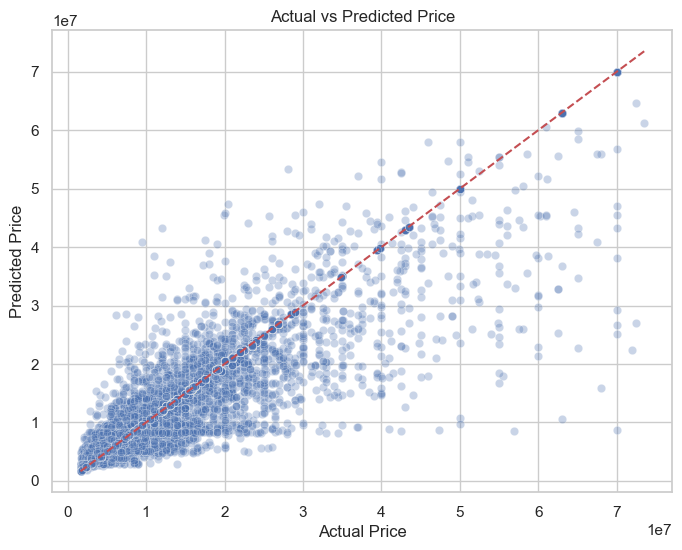

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# استخدام y_test.values يضمن عدم حدوث تعارض في الفهارس والأطوال
sns.scatterplot(
    x=y_test.values,
    y=pred_real,
    alpha=0.3
)

# رسم الخط الأحمر المائل للتوقع المثالي
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

In [114]:
import joblib
import json

# حفظ قائمة المناطق
with open("locations.json", "w", encoding="utf-8") as f:
    json.dump(
        sorted(df_clean["location_grouped"].unique().tolist()),
        f,
        ensure_ascii=False
    )

# حفظ الموديل
joblib.dump(model, "house_price.pkl")

print("Model and locations saved successfully.")

Model and locations saved successfully.


In [115]:
import os 
print(os.getcwd())

c:\Users\CityLap\Downloads
